In [1]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
DATA_DIR = "../data"
IMG_DIRS = ["imgs_part_1", "imgs_part_2", "imgs_part_3"]
CSV_PATH = os.path.join(DATA_DIR, "metadata.csv")


NUM_CLASSES = 6
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4
IMAGE_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


print("Using device:", DEVICE)

Using device: cuda


In [3]:
# CELL [3] - Load & Encode Metadata (PAD-UFES-20)

df = pd.read_csv(CSV_PATH)

# Giữ các cột cần thiết
keep_cols = [
    "img_id",
    "diagnostic",
    "age",
    "gender",
    "itch",
    "grew",
    "bleed"
]
df = df[keep_cols]

# ---------- ENCODE METADATA ----------
# Gender
df["gender"] = df["gender"].map({
    "MALE": 1,
    "FEMALE": 0
})

# YES / NO → 1 / 0
yn_map = {
    "YES": 1,
    "NO": 0,
    "Y": 1,
    "N": 0
}

for col in ["itch", "grew", "bleed"]:
    df[col] = df[col].map(yn_map)

# Age: fill missing with mean
df["age"] = df["age"].fillna(df["age"].mean())

# Fill any remaining NaN with 0
df = df.fillna(0)

print("Columns & dtypes:")
print(df.dtypes)
print("Total samples:", len(df))


Columns & dtypes:
img_id         object
diagnostic     object
age             int64
gender        float64
itch          float64
grew          float64
bleed         float64
dtype: object
Total samples: 2298


In [4]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["diagnostic"])


print("Classes:", list(label_encoder.classes_))

Classes: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']


In [5]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)


print("Train size:", len(train_df))
print("Val size:", len(val_df))

Train size: 1838
Val size: 460


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),            
    transforms.RandomRotation(degrees=20),           
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

In [ ]:

class SkinDataset(Dataset):
    def __init__(self, dataframe, data_dir, img_dirs, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.data_dir = data_dir
        self.img_dirs = img_dirs
        self.transform = transform

        # Metadata columns
        self.meta_cols = ["age", "gender", "itch", "grew", "bleed"]

        # Fill missing values
        self.df[self.meta_cols] = self.df[self.meta_cols].fillna(0)

    def __len__(self):
        return len(self.df)

    def _find_image_path(self, img_name):
        for d in self.img_dirs:
            path = os.path.join(self.data_dir, d, img_name)
            if os.path.exists(path):
                return path
        return None

    def __getitem__(self, idx):
        row = self.df.loc[idx]

        # ----- Image -----
        img_path = self._find_image_path(row["img_id"])
        if img_path is None:
            return self.__getitem__((idx + 1) % len(self.df))

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # ----- Metadata -----
        meta = row[self.meta_cols].values.astype("float32")
        meta = torch.tensor(meta)

        # ----- Label -----
        label = torch.tensor(row["label"], dtype=torch.long)

        return image, meta, label


In [8]:
train_dataset = SkinDataset(train_df, DATA_DIR, IMG_DIRS, train_transform)
val_dataset = SkinDataset(val_df, DATA_DIR, IMG_DIRS, val_transform)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
class SkinNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Load pre-trained weights
        self.cnn = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

        #  FINE-TUNING 
        for param in self.cnn.parameters():
            param.requires_grad = True

        # Thay thế classifier mặc định
        in_features = self.cnn.classifier[1].in_features
        self.cnn.classifier = nn.Identity()

        self.image_fc = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.BatchNorm1d(128),  
            nn.ReLU(),
            nn.Dropout(0.3)       
        )

        # Metadata branch
        self.meta_fc = nn.Sequential(
            nn.Linear(5, 32),
            nn.BatchNorm1d(32),
            nn.ReLU()
        )

        # Fusion
        self.classifier = nn.Linear(128 + 32, num_classes)

    def forward(self, image, meta):
        img_feat = self.cnn(image)
        img_feat = self.image_fc(img_feat)

        meta_feat = self.meta_fc(meta)

        fused = torch.cat([img_feat, meta_feat], dim=1)
        return self.classifier(fused)

model = SkinNet(NUM_CLASSES).to(DEVICE)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Tính toán Class Weights từ tập Train
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

# Chuyển sang Tensor và đưa vào Device (GPU)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print("Class Weights:", class_weights)


Class Weights: tensor([0.5245, 0.4532, 7.2937, 1.5709, 2.0022, 1.6294], device='cuda:0')


In [ ]:
# Cập nhật Loss function với trọng số
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, meta, labels in tqdm(loader):
        images = images.to(DEVICE)
        meta   = meta.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images, meta)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total


def validate(model, loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, meta, labels in tqdm(loader):
            images = images.to(DEVICE)
            meta   = meta.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images, meta)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / len(loader), correct / total


In [ ]:

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    verbose=True
)



Cell [11.5] done: scheduler ready


c:\Python12\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
EPOCHS = 15  # Tăng thêm epoch vì fine-tuning cần nhiều thời gian hơn
best_val_acc = 0.0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    # Validate
    val_loss, val_acc = validate(
        model, val_loader, criterion
    )

    # Scheduler sẽ giảm LR nếu val_acc không cải thiện
    scheduler.step(val_acc)

    # In Learning Rate hiện tại
    curr_lr = optimizer.param_groups[0]['lr']
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | LR: {curr_lr:.6f}")

    # Lưu model tốt nhất
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_skinnet.pth")
        print("--> Saved Best Model!")


Epoch 1/15


100%|██████████| 15/15 [00:21<00:00,  1.42s/it]


Train Loss: 1.6880 | Train Acc: 0.3275
Val   Loss: 1.5043 | Val   Acc: 0.4087 | LR: 0.000100
--> Saved Best Model!

Epoch 2/15


100%|██████████| 15/15 [00:18<00:00,  1.22s/it]


Train Loss: 1.3498 | Train Acc: 0.4450
Val   Loss: 1.2532 | Val   Acc: 0.4652 | LR: 0.000100
--> Saved Best Model!

Epoch 3/15


...

Train Loss: 0.3688 | Train Acc: 0.8526
Val   Loss: 0.8126 | Val   Acc: 0.7174 | LR: 0.000100
--> Saved Best Model!

Epoch 14/15


100%|██████████| 15/15 [00:18<00:00,  1.24s/it]


Train Loss: 0.3375 | Train Acc: 0.8694
Val   Loss: 0.8718 | Val   Acc: 0.7043 | LR: 0.000100

Epoch 15/15


100%|██████████| 15/15 [00:19<00:00,  1.33s/it]

Train Loss: 0.3141 | Train Acc: 0.8732
Val   Loss: 0.8478 | Val   Acc: 0.7304 | LR: 0.000100
--> Saved Best Model!


In [ ]:
#  Save Multimodal Model

MODEL_PATH = "skinnet_image_metadata.pth"
torch.save(model.state_dict(), MODEL_PATH)

print("Cell [13] done: multimodal model saved")


Cell [13] done: multimodal model saved


C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_15232\229740321.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_skinnet.pth"))


Đã load trọng số từ best_skinnet.pth
Đang chạy đánh giá...


100%|██████████| 15/15 [00:17<00:00,  1.17s/it]



BÁO CÁO KẾT QUẢ CHI TIẾT
              precision    recall  f1-score   support

         ACK       0.80      0.79      0.80       146
         BCC       0.78      0.74      0.76       169
         MEL       0.64      0.70      0.67        10
         NEV       0.73      0.88      0.80        49
         SCC       0.34      0.31      0.32        39
         SEK       0.66      0.70      0.68        47

    accuracy                           0.73       460
   macro avg       0.66      0.69      0.67       460
weighted avg       0.73      0.73      0.73       460



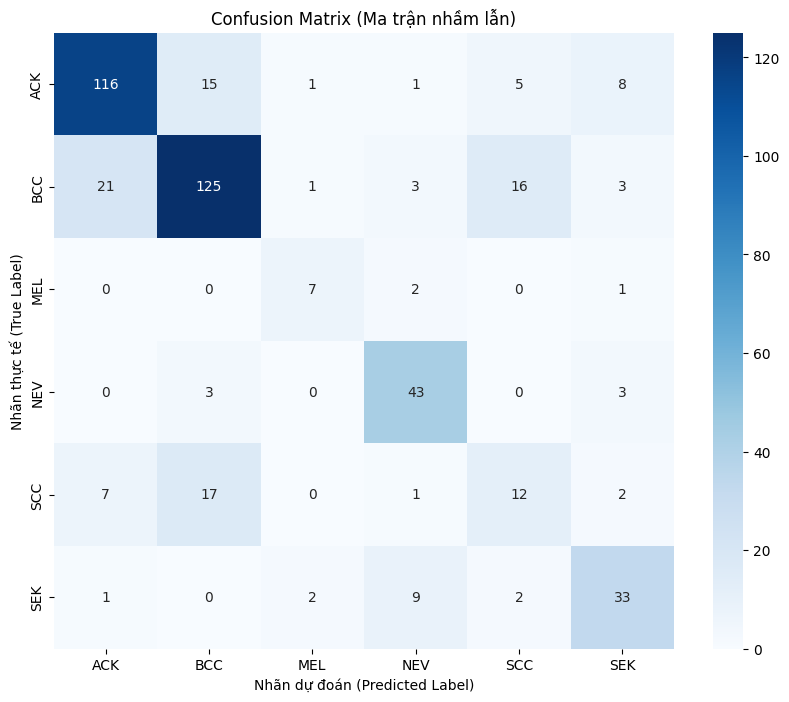

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

# 1. Load lại model tốt nhất đã lưu 
if os.path.exists("best_skinnet.pth"):
    model.load_state_dict(torch.load("best_skinnet.pth"))
    print("Đã load trọng số từ best_skinnet.pth")
else:
    print("Không tìm thấy file best_skinnet.pth, sử dụng model hiện tại.")

model.eval() # Chuyển sang chế độ đánh giá 
model.to(DEVICE)

# 2. Chạy dự đoán trên tập Validation
all_preds = []
all_labels = []

print("Đang chạy đánh giá...")
with torch.no_grad(): # Tắt tính toán gradient để tiết kiệm bộ nhớ
    for images, meta, labels in tqdm(val_loader):
        images = images.to(DEVICE)
        meta = meta.to(DEVICE)
        labels = labels.to(DEVICE)

        # Forward pass
        outputs = model(images, meta)
        
        # Lấy nhãn dự đoán (lớp có xác suất cao nhất)
        _, preds = torch.max(outputs, 1)

        # Lưu lại kết quả
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Tính toán và In báo cáo chi tiết 
class_names = list(label_encoder.classes_)

print("\n" + "="*30)
print("BÁO CÁO KẾT QUẢ CHI TIẾT")
print("="*30)
print(classification_report(all_labels, all_preds, target_names=class_names))

# 4. Vẽ Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix (Ma trận nhầm lẫn)')
plt.ylabel('Nhãn thực tế (True Label)')
plt.xlabel('Nhãn dự đoán (Predicted Label)')
plt.show()